# Notebook Avances Laboratorio 4
Este notebook contiene los avances requeridos para el Laboratorio 4

## 0. Configuración

**Librerías**

In [18]:
# pip install openeo -q

In [35]:
import openeo
import os
from datetime import datetime, timedelta
import glob
import re
import numpy as np
import rasterio
import pandas as pd
import matplotlib.pyplot as plt

**Funciones**

In [37]:
# Paso 1
def conectar_sentinel2():
    """
    Establece y autentica la conexión con el backend de openEO
    de Copernicus Data Space Ecosystem.

    Returns
    -------
    openeo.Connection
        Conexión autenticada, lista para hacer consultas de datos.
    """
    connection = openeo.connect("https://openeo.dataspace.copernicus.eu")

    # Autenticación OIDC (interactiva la primera vez).
    # Si prefieres usar client credentials (usuario/contraseña de servicio)
    # en vez del flujo interactivo, se puede configurar por variables de
    # entorno OPENEO_AUTH_METHOD, OPENEO_AUTH_CLIENT_ID, etc.
    connection.authenticate_oidc()

    return connection


def verificar_conexion(connection):
    """
    Verifica que la conexión esté activa y que la colección
    SENTINEL2_L2A (Nivel 2A, reflectancia de superficie corregida
    atmosféricamente) esté disponible.
    """
    print("Conectado a:", connection.root_url)

    colecciones = [c["id"] for c in connection.list_collections()]
    assert "SENTINEL2_L2A" in colecciones, (
        "No se encontró la colección SENTINEL2_L2A en este backend."
    )
    print("Colección SENTINEL2_L2A disponible: OK")

    # Metadata de la colección (bandas disponibles, resolución, etc.)
    metadata = connection.describe_collection("SENTINEL2_L2A")
    bandas = [b["name"] for b in metadata["summaries"]["eo:bands"]]
    print("Bandas disponibles:", bandas)


# Paso 2
def _rango_de_un_dia(fecha_str):
    """Convierte 'YYYY-MM-DD' en un rango [inicio, fin) de un solo día,
    formato que openEO/STAC requiere para temporal_extent."""
    inicio = datetime.strptime(fecha_str, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)
    return [inicio.strftime("%Y-%m-%d"), fin.strftime("%Y-%m-%d")]


def descargar_escena(connection, bbox, fecha_str, nombre_lago, output_dir=OUTPUT_DIR):
    """
    Descarga únicamente las bandas necesarias (B03, B04, B05, B08) para
    un lago y una fecha específica, recortado al bounding box del lago.

    Guarda el resultado como GeoTIFF multibanda en:
        {output_dir}/{nombre_lago}_{fecha}.tif
    """
    os.makedirs(output_dir, exist_ok=True)
    ruta_salida = os.path.join(output_dir, f"{nombre_lago}_{fecha_str}.tif")

    if os.path.exists(ruta_salida):
        print(f"  [skip] ya existe: {ruta_salida}")
        return ruta_salida

    spatial_extent = {
        "west": bbox["west"],
        "south": bbox["south"],
        "east": bbox["east"],
        "north": bbox["north"],
    }

    cubo = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=spatial_extent,
        temporal_extent=_rango_de_un_dia(fecha_str),
        bands=BANDAS_NECESARIAS,
    )

    # Reduce la dimensión temporal (debería quedar 1 sola escena por rango
    # de 1 día); tomamos la mediana por seguridad ante duplicados de tile.
    cubo = cubo.reduce_dimension(dimension="t", reducer="median")

    print(f"  Descargando {nombre_lago} - {fecha_str} ...")
    cubo.download(ruta_salida, format="GTiff")
    print(f"  OK -> {ruta_salida}")
    return ruta_salida


def descargar_todo(connection):
    """Descarga las 22 combinaciones lago-fecha (11 Atitlán + 11 Amatitlán)."""
    rutas = {}

    print("=== Lago Atitlán ===")
    rutas["atitlan"] = [
        descargar_escena(connection, LAGO_ATITLAN, fecha, "atitlan")
        for fecha in FECHAS_ATITLAN
    ]

    print("=== Lago Amatitlán ===")
    rutas["amatitlan"] = [
        descargar_escena(connection, LAGO_AMATITLAN, fecha, "amatitlan")
        for fecha in FECHAS_AMATITLAN
    ]

    return rutas

# Paso 3
def leer_bandas(ruta_tif):
    """
    Lee un GeoTIFF de 7 bandas y devuelve un diccionario {nombre_banda: array},
    además de la metadata espacial (para poder escribir resultados georreferenciados).
    """
    with rasterio.open(ruta_tif) as src:
        arr = src.read().astype("float32")
        meta = src.meta.copy()

    bandas = {nombre: arr[i] for i, nombre in enumerate(ORDEN_BANDAS)}
    return bandas, meta


def _safe_divide(numerador, denominador):
    """División segura que evita warnings/errores por división entre 0."""
    with np.errstate(divide="ignore", invalid="ignore"):
        resultado = np.where(denominador != 0, numerador / denominador, np.nan)
    return resultado


def calcular_ndvi(bandas):
    b04, b08 = bandas["B04"], bandas["B08"]
    return _safe_divide(b08 - b04, b08 + b04)


def calcular_ndwi(bandas):
    b03, b08 = bandas["B03"], bandas["B08"]
    return _safe_divide(b03 - b08, b03 + b08)


def calcular_mascara_agua(bandas, ndvi=None):
    """
    Replica la función wbi() del script original: combina varios índices
    de agua (MNDWI, NDWI, AWEI_sh, AWEI_nsh, NDVI) y aplica un filtro para
    excluir falsos positivos de zonas urbanas y suelo desnudo.

    Retorna una máscara booleana: True = agua, False = tierra.
    """
    b02, b03, b04 = bandas["B02"], bandas["B03"], bandas["B04"]
    b08, b11, b12 = bandas["B08"], bandas["B11"], bandas["B12"]

    if ndvi is None:
        ndvi = calcular_ndvi(bandas)

    mndwi = _safe_divide(b03 - b11, b03 + b11)
    ndwi = _safe_divide(b03 - b08, b03 + b08)
    aweish = b02 + 2.5 * b03 - 1.5 * (b08 + b11) - 0.25 * b12
    aweinsh = 4 * (b03 - b11) - (0.25 * b08 + 2.75 * b11)

    es_agua = (
        (mndwi > MNDWI_THRESHOLD)
        | (ndwi > NDWI_THRESHOLD)
        | (aweinsh > 0.1879)
        | (aweish > 0.1112)
        | (ndvi < -0.2)
    )

    # Filtro de zonas urbanas / suelo desnudo (UABS) sobre los píxeles
    # clasificados como agua: dbsi = (swir1-green)/(swir1+green) - ndvi
    dbsi = _safe_divide(b11 - b03, b11 + b03) - ndvi
    falso_positivo = (aweinsh <= -0.03) | (dbsi > 0)

    mascara = es_agua & ~falso_positivo
    return mascara


def calcular_cianobacteria(bandas):
    """
    Calcula el NDCI y la estimación de clorofila-a asociada a cianobacteria
    (fórmula empírica de Kravitz & Matthews, 2020).
    """
    b04, b05 = bandas["B04"], bandas["B05"]
    ndci = _safe_divide(b05 - b04, b05 + b04)
    chl = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    return ndci, chl


def procesar_escena(ruta_tif):
    """
    Procesa un GeoTIFF: calcula NDVI, NDWI, máscara de agua, NDCI y chl-a
    (cianobacteria), enmascara todo con la máscara de agua, y devuelve un
    diccionario con los arrays resultantes + la metadata espacial.
    """
    bandas, meta = leer_bandas(ruta_tif)

    ndvi = calcular_ndvi(bandas)
    ndwi = calcular_ndwi(bandas)
    mascara_agua = calcular_mascara_agua(bandas, ndvi=ndvi)
    ndci, chl = calcular_cianobacteria(bandas)

    # Enmascarar: fuera del agua -> NaN (no nos interesa tierra en el análisis)
    ndvi_agua = np.where(mascara_agua, ndvi, np.nan)
    ndwi_agua = np.where(mascara_agua, ndwi, np.nan)
    ndci_agua = np.where(mascara_agua, ndci, np.nan)
    chl_agua = np.where(mascara_agua, chl, np.nan)

    return {
        "ndvi": ndvi_agua,
        "ndwi": ndwi_agua,
        "ndci": ndci_agua,
        "chl_cianobacteria": chl_agua,
        "mascara_agua": mascara_agua.astype("float32"),
        "meta": meta,
    }


def guardar_resultado(resultado, ruta_salida):
    """
    Guarda ndvi, ndwi, ndci, chl_cianobacteria y mascara_agua como un
    GeoTIFF multibanda (5 bandas), conservando la georreferenciación
    original, listo para mapear (Ejercicio 5) o resumir (Ejercicio 4).
    """
    os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

    orden_salida = ["ndvi", "ndwi", "ndci", "chl_cianobacteria", "mascara_agua"]
    meta = resultado["meta"].copy()
    meta.update(count=len(orden_salida), dtype="float32", nodata=np.nan)

    with rasterio.open(ruta_salida, "w", **meta) as dst:
        for i, nombre in enumerate(orden_salida, start=1):
            dst.write(resultado[nombre].astype("float32"), i)
        dst.descriptions = tuple(orden_salida)


def procesar_todo(raw_dir=RAW_DIR, processed_dir=PROCESSED_DIR):
    """Procesa todos los GeoTIFF crudos en raw_dir y guarda los resultados
    en processed_dir con el mismo nombre de archivo."""
    rutas_crudas = sorted(glob.glob(os.path.join(raw_dir, "*.tif")))
    if not rutas_crudas:
        print(f"No se encontraron archivos .tif en {raw_dir}")
        return []

    rutas_procesadas = []
    for ruta in rutas_crudas:
        nombre = os.path.basename(ruta)
        ruta_salida = os.path.join(processed_dir, nombre)
        print(f"Procesando {nombre} ...")
        resultado = procesar_escena(ruta)
        guardar_resultado(resultado, ruta_salida)
        rutas_procesadas.append(ruta_salida)
        print(f"  OK -> {ruta_salida}")

    return rutas_procesadas

def _parsear_nombre(ruta_tif):
    """Extrae (lago, fecha) del nombre de archivo, ej: 'atitlan_2025-01-18.tif'."""
    nombre = os.path.basename(ruta_tif)
    match = NOMBRE_PATRON.match(nombre)
    if not match:
        raise ValueError(f"Nombre de archivo inesperado: {nombre}")
    lago, fecha = match.groups()
    return lago, fecha


def calcular_estadisticas_escena(ruta_tif):
    """
    Lee un GeoTIFF procesado (Ejercicio 3) y calcula estadísticas resumen
    para una escena (un lago, una fecha): promedio de cianobacteria,
    NDVI, NDWI, y porcentaje del bbox cubierto por agua.
    """
    lago, fecha = _parsear_nombre(ruta_tif)

    with rasterio.open(ruta_tif) as src:
        ndvi = src.read(BANDA_NDVI)
        ndwi = src.read(BANDA_NDWI)
        ndci = src.read(BANDA_NDCI)
        chl = src.read(BANDA_CHL)
        mascara = src.read(BANDA_MASCARA)

    return {
        "lago": NOMBRES_LAGOS[lago],
        "fecha": pd.to_datetime(fecha),
        "chl_promedio": np.nanmean(chl),
        "chl_std": np.nanstd(chl),
        "ndvi_promedio": np.nanmean(ndvi),
        "ndwi_promedio": np.nanmean(ndwi),
        "ndci_promedio": np.nanmean(ndci),
        "pct_pixeles_agua": np.nanmean(mascara) * 100,
        "archivo": os.path.basename(ruta_tif),
    }


def construir_serie_temporal(processed_dir=PROCESSED_DIR):
    """
    Recorre todos los GeoTIFF procesados y arma un DataFrame con una fila
    por (lago, fecha), ordenado cronológicamente dentro de cada lago.
    """
    rutas = sorted(glob.glob(os.path.join(processed_dir, "*.tif")))
    if not rutas:
        raise FileNotFoundError(
            f"No se encontraron archivos procesados en {processed_dir}. "
            "Corre primero el Ejercicio 3 (procesar_todo())."
        )

    filas = [calcular_estadisticas_escena(r) for r in rutas]
    df = pd.DataFrame(filas)
    df = df.sort_values(["lago", "fecha"]).reset_index(drop=True)
    return df


def identificar_picos(df, columna="chl_promedio", umbral_std=1.0):
    """
    Marca como "pico" cualquier fecha donde el índice de cianobacteria
    del lago supera (media + umbral_std * desviación estándar) de la
    serie de ese mismo lago. Devuelve el DataFrame con una columna
    booleana adicional 'es_pico'.
    """
    df = df.copy()
    df["es_pico"] = False

    for lago, grupo in df.groupby("lago"):
        media = grupo[columna].mean()
        std = grupo[columna].std()
        umbral = media + umbral_std * std
        df.loc[grupo.index, "es_pico"] = grupo[columna] > umbral

    return df


def graficar_evolucion_temporal(df, columna="chl_promedio", ruta_salida=None):
    """
    Grafica la evolución temporal del índice de cianobacteria, una línea
    por lago, marcando los picos identificados.
    """
    fig, ax = plt.subplots(figsize=(11, 6))
    pico_ya_en_leyenda = False

    for lago, grupo in df.groupby("lago"):
        grupo = grupo.sort_values("fecha")
        ax.plot(
            grupo["fecha"], grupo[columna],
            marker="o", label=lago, linewidth=2,
        )
        picos = grupo[grupo["es_pico"]]
        if not picos.empty:
            ax.scatter(
                picos["fecha"], picos[columna],
                s=120, facecolors="none", edgecolors="red",
                linewidths=2, zorder=5,
                label="Pico identificado" if not pico_ya_en_leyenda else None,
            )
            pico_ya_en_leyenda = True

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Índice de cianobacteria (chl, promedio por escena)")
    ax.set_title("Evolución temporal del índice de cianobacteria por lago")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()
    fig.tight_layout()

    if ruta_salida:
        os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)
        fig.savefig(ruta_salida, dpi=150)
        print(f"Gráfico guardado en: {ruta_salida}")

    return fig, ax


def resumen_fechas_criticas(df):
    """Imprime un resumen legible de las fechas marcadas como picos, por lago."""
    picos = df[df["es_pico"]].sort_values(["lago", "fecha"])
    if picos.empty:
        print("No se identificaron picos por encima del umbral definido.")
        return picos

    print("Fechas críticas identificadas (posibles picos de floración):\n")
    for lago, grupo in picos.groupby("lago"):
        print(f"  {lago}:")
        for _, fila in grupo.iterrows():
            print(
                f"    - {fila['fecha'].date()}  "
                f"chl={fila['chl_promedio']:.2f}  "
                f"(cobertura de agua analizada: {fila['pct_pixeles_agua']:.1f}%)"
            )
    return picos


**Parámetros**

In [30]:
# -----------------------------------------------------------------------
# Coordenadas de los lagos
# -----------------------------------------------------------------------
LAGO_ATITLAN = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979,
}

LAGO_AMATITLAN = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799,
}

# -----------------------------------------------------------------------
# Fechas para acceder a las imágenes
# -----------------------------------------------------------------------

FECHAS_ATITLAN = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

FECHAS_AMATITLAN = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

# -----------------------------------------------------------------------
# Espectro a analizar
# -----------------------------------------------------------------------

BANDAS_NECESARIAS = ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]

# -----------------------------------------------------------------------
# Ruta para guardar los rasters
# -----------------------------------------------------------------------

OUTPUT_DIR = "data/raw"


RAW_DIR = "data/raw"
PROCESSED_DIR = "data/processed"

# Orden de bandas tal como se descargaron en el Ejercicio 2
ORDEN_BANDAS = ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]

# Umbrales recomendados por el script original (Kravitz & Matthews, 2020)
MNDWI_THRESHOLD = 0.42
NDWI_THRESHOLD = 0.40

In [36]:
PROCESSED_DIR = "data/processed"
FIGURES_DIR = "figuras"

NOMBRE_PATRON = re.compile(r"^(atitlan|amatitlan)_(\d{4}-\d{2}-\d{2})\.tif$")

# Bandas tal como las guardó el Ejercicio 3
BANDA_NDVI = 1
BANDA_NDWI = 2
BANDA_NDCI = 3
BANDA_CHL = 4
BANDA_MASCARA = 5

NOMBRES_LAGOS = {"atitlan": "Atitlán", "amatitlan": "Amatitlán"}

## 1. Obtener Data

In [26]:
conn = conectar_sentinel2()
verificar_conexion(conn)

Authenticated using refresh token.
Conectado a: https://openeo.dataspace.copernicus.eu/openeo/1.2/
Colección SENTINEL2_L2A disponible: OK
Bandas disponibles: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'WVP', 'AOT', 'SCL', 'sunAzimuthAngles', 'sunZenithAngles', 'viewAzimuthMean', 'viewZenithMean', 'CLD', 'SNW']


In [ ]:
conn = conectar_sentinel2()
rutas_descargadas = descargar_todo(conn)
print("\nDescarga completa.")
print(f"Atitlán: {len(rutas_descargadas['atitlan'])} archivos")
print(f"Amatitlán: {len(rutas_descargadas['amatitlan'])} archivos")


Authenticated using refresh token.
=== Lago Atitlán ===
  Descargando atitlan - 2025-01-18 ...
  OK -> data/raw/atitlan_2025-01-18.tif
  Descargando atitlan - 2025-04-13 ...
  OK -> data/raw/atitlan_2025-04-13.tif
  Descargando atitlan - 2025-05-13 ...
  OK -> data/raw/atitlan_2025-05-13.tif
  Descargando atitlan - 2025-07-17 ...
  OK -> data/raw/atitlan_2025-07-17.tif
  Descargando atitlan - 2025-11-21 ...
  OK -> data/raw/atitlan_2025-11-21.tif
  Descargando atitlan - 2025-12-29 ...
  OK -> data/raw/atitlan_2025-12-29.tif
  Descargando atitlan - 2026-02-12 ...


## 2. Índice de Cianobacteria

### 2.1 Obtener Capas Necesarias

In [32]:
procesar_todo()

Procesando amatitlan_2025-01-28.tif ...


  OK -> data/processed/amatitlan_2025-01-28.tif
Procesando amatitlan_2025-04-15.tif ...


  OK -> data/processed/amatitlan_2025-04-15.tif
Procesando amatitlan_2025-04-28.tif ...


  OK -> data/processed/amatitlan_2025-04-28.tif
Procesando amatitlan_2025-11-24.tif ...


  OK -> data/processed/amatitlan_2025-11-24.tif
Procesando amatitlan_2026-01-08.tif ...


...

  OK -> data/processed/atitlan_2026-03-24.tif
Procesando atitlan_2026-04-13.tif ...


  OK -> data/processed/atitlan_2026-04-13.tif
Procesando atitlan_2026-04-28.tif ...


  OK -> data/processed/atitlan_2026-04-28.tif
Procesando atitlan_2026-07-22.tif ...


  OK -> data/processed/atitlan_2026-07-22.tif


['data/processed/amatitlan_2025-01-28.tif',
 'data/processed/amatitlan_2025-04-15.tif',
 'data/processed/amatitlan_2025-04-28.tif',
 'data/processed/amatitlan_2025-11-24.tif',
 'data/processed/amatitlan_2026-01-08.tif',
 'data/processed/amatitlan_2026-02-02.tif',
 'data/processed/amatitlan_2026-02-07.tif',
 'data/processed/amatitlan_2026-03-29.tif',
 'data/processed/amatitlan_2026-04-13.tif',
 'data/processed/amatitlan_2026-04-28.tif',
 'data/processed/amatitlan_2026-06-19.tif',
 'data/processed/atitlan_2025-01-18.tif',
 'data/processed/atitlan_2025-04-13.tif',
 'data/processed/atitlan_2025-05-13.tif',
 'data/processed/atitlan_2025-07-17.tif',
 'data/processed/atitlan_2025-11-21.tif',
 'data/processed/atitlan_2025-12-29.tif',
 'data/processed/atitlan_2026-02-12.tif',
 'data/processed/atitlan_2026-03-24.tif',
 'data/processed/atitlan_2026-04-13.tif',
 'data/processed/atitlan_2026-04-28.tif',
 'data/processed/atitlan_2026-07-22.tif']

### 2.2 Análisis Temporal

     lago      fecha  chl_promedio  pct_pixeles_agua
Amatitlán 2025-01-28     14.567988          9.286998
Amatitlán 2025-04-15      8.022193         10.351851
Amatitlán 2025-04-28     13.287254         10.505004
Amatitlán 2025-11-24     13.603077          9.741805
Amatitlán 2026-01-08     23.804863         10.674354
Amatitlán 2026-02-02      6.741730          2.257120
Amatitlán 2026-02-07      7.876098          5.730964
Amatitlán 2026-03-29     15.232273         10.992447
Amatitlán 2026-04-13     16.630243         11.491516
Amatitlán 2026-04-28     25.924120         10.930143
Amatitlán 2026-06-19     63.993996         10.686703
  Atitlán 2025-01-18   1492.124634         23.254852
  Atitlán 2025-04-13      2.870466         24.009912
  Atitlán 2025-05-13      3.174237         21.213043
  Atitlán 2025-07-17     -6.359355         22.385862
  Atitlán 2025-11-21  -1825.436401         21.904720
  Atitlán 2025-12-29     85.648338         22.663052
  Atitlán 2026-02-12   -147.608276         22.

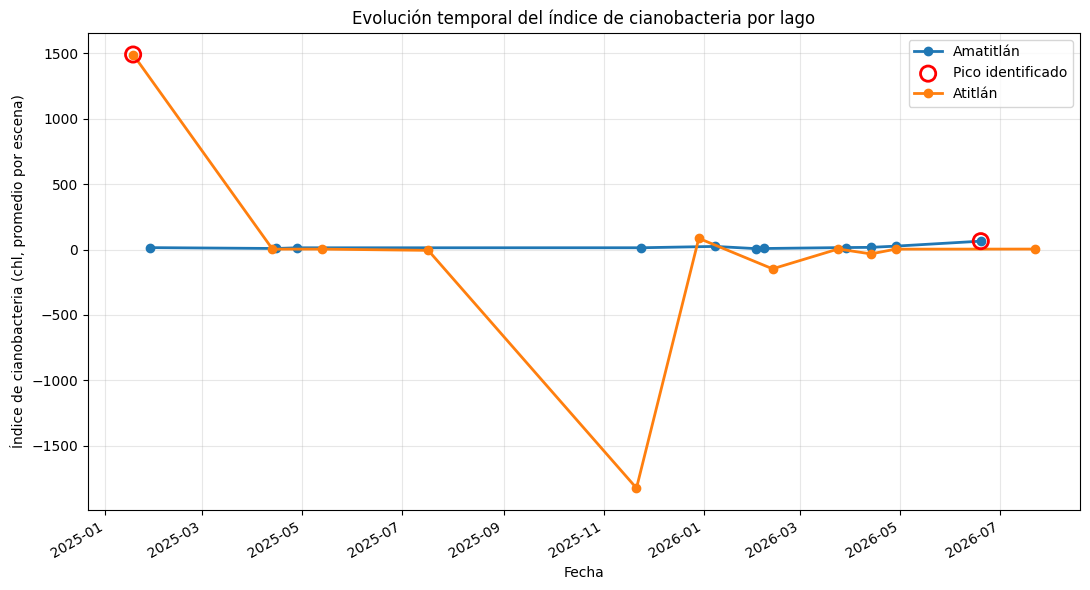

In [38]:
df_temporal = construir_serie_temporal()
df_temporal = identificar_picos(df_temporal)

print(df_temporal[
        ["lago", "fecha", "chl_promedio", "pct_pixeles_agua"]
    ].to_string(index=False))
print()

resumen_fechas_criticas(df_temporal)

graficar_evolucion_temporal(
        df_temporal,
        ruta_salida=os.path.join(FIGURES_DIR, "evolucion_temporal_cianobacteria.png"),
    )

df_temporal.to_csv("data/serie_temporal_cianobacteria.csv", index=False)
print("\nTabla guardada en: data/serie_temporal_cianobacteria.csv")


Resulta interesesante que en la gráfica la serie correspondiente al lago de Atitlán tenga una mayor varianza, esto probablemente se deba a eventos puntuales como el vertimiento de una alta cantidad de residuos en el cuerpo de agua en enero del 2025 o como consecuencia de la temporada de lluvia del año 2024, que va de mayo a octubre, la cual pudo contribuir a una mayor afluencia de contaminación lo cual se ve reflejado en el año siguiente. Fuera de estos picos, el lago de Atitlán presenta un menor índice de de cianobacteria y esto se podría deber a que se encuentra menos contaminado. El pico del lago de Amatitlán se podría explicar también como consecuencia de una mayor afluencia de residuos o vertimiento de sustancias debido a las lluvias.